<img src="https://drive.google.com/thumbnail?id=1aGdhe9rGzHRwJqiuzMT0OZdv-dB1mRuZ&sz=w1200">

## Извлечение признаков

### Текст

Мама мыла раму


- Токенизация
  -  [‘Мама’, ‘мыла’, ‘раму’]

- Нормализация
  - [‘Мама’, ‘мыть’, ‘рама’]

- Векторизация
  - [[1, 0, 0], [0, 1, 0], [0, 0, 1]]


### Геоданные

- Получение координат
- Расчет близости объектов
- Подсчет объектов рядом


### Дата

In [1]:
import pandas as pd

In [2]:
data = pd.DataFrame(
    {'date':[
    '2020-05-14',
    '2022-08-23',
    '2019-01-01'
]})

data

,date
0,2020-05-14
1,2022-08-23
2,2019-01-01


In [3]:
data['date']

0    2020-05-14
1    2022-08-23
2    2019-01-01
Name: date, dtype: object

In [4]:
data['date'] = pd.to_datetime(data['date'])
data['date']

0   2020-05-14
1   2022-08-23
2   2019-01-01
Name: date, dtype: datetime64[ns]

In [5]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['weekday'] = data['date'].dt.weekday

data

,date,year,month,day,weekday
0,2020-05-14,2020,5,14,3
1,2022-08-23,2022,8,23,1
2,2019-01-01,2019,1,1,1


## Конструирование признаков

https://drive.google.com/file/d/14XsCd9OBw7aVahtaQ5ZBYPpf02O2vnwU/view?usp=sharing

In [6]:
!gdown 14XsCd9OBw7aVahtaQ5ZBYPpf02O2vnwU -O data.csv

Downloading...
From: https://drive.google.com/uc?id=14XsCd9OBw7aVahtaQ5ZBYPpf02O2vnwU
To: D:\MyJupyterNotebook\Learning\GitHub\01_data_analysis\data.csv

  0%|          | 0.00/1.46M [00:00<?, ?B/s]
 36%|###5      | 524k/1.46M [00:00<00:00, 1.14MB/s]
100%|##########| 1.46M/1.46M [00:00<00:00, 2.28MB/s]
100%|##########| 1.46M/1.46M [00:00<00:00, 2.06MB/s]


In [7]:
data = pd.read_csv('data.csv')
data.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,usecode,yearbuilt,zestimate,zipcode
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,02/17/2016,1300000.0,37.778705,-122.412635,South of Market,4,Condominium,2007.0,1167508.0,94103.0
1,260 King St UNIT 475,1.0,1.0,903.0,02/17/2016,750000.0,37.777641,-122.393417,South of Market,3,Condominium,2004.0,823719.0,94107.0
2,560 Missouri St # B,4.0,3.0,1425.0,02/17/2016,1495000.0,37.759198,-122.396516,Potrero Hill,6,Condominium,2003.0,1708594.0,94107.0
3,350 Missouri St,3.0,3.0,2231.0,02/17/2016,2700000.0,37.761886,-122.396769,Potrero Hill,10,SingleFamily,1927.0,2411236.0,94107.0
4,3658 Folsom St,3.0,3.0,1300.0,02/17/2016,1530000.0,37.740795,-122.413453,Bernal Heights,4,SingleFamily,1900.0,1918539.0,94110.0


In [8]:
data.shape

(11330, 14)

In [9]:
data.isna().sum()

z_address        0
bathrooms        0
bedrooms         0
finishedsqft     0
lastsolddate     0
lastsoldprice    0
latitude         0
longitude        0
neighborhood     0
totalrooms       0
usecode          0
yearbuilt        0
zestimate        0
zipcode          0
dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


def get_score(X, y, random_seed=42, model=None, is_return=False):
  if model is None:
      model = LinearRegression()

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)


  model.fit(X_train, y_train)
  if is_return:
      print(model.score(X_test, y_test))
      return model

  return model.score(X_test, y_test)

### Обработка категориальных признаков

#### OneHotEncoding/dummies

<img src='https://miro.medium.com/max/1400/1*ggtP4a5YaRx6l09KQaYOnw.png'>

In [11]:
# red - 0
# blue - 1
# green - 2


# школу - 0
# колледж - 1
# бакалавр - 2

# ...



#### LabelEncoding

<img src='https://d1m75rqqgidzqn.cloudfront.net/wp-data/2020/08/11155757/image-37.png'>


#### Frequency/Count Encoding

In [12]:
# 100

# # Count Encoding
# школу - 20
# колледж - 20
# бакалавр - 60

# # Frequency Encoding
# школу - 0.2
# колледж - 0.2
# бакалавр - 0.6

<img src='https://miro.medium.com/max/1400/1*8xaCz_mAEgb4YXhQnoRGfg.png'>

#### Target Encoding

<img src="https://drive.google.com/thumbnail?id=1_mbGBmtroHgnupgfW68aiRl5vjmTODSj&sz=w600">

### Задачка

In [14]:
# !pip install category_encoders

In [15]:
from sklearn.preprocessing import LabelEncoder
from category_encoders.count import CountEncoder


def get_one_hot(X, cols):
    for each in cols:
        dummies = pd.get_dummies(X[each], prefix=each)
        X = pd.concat([X, dummies], axis=1)
    return X

def get_label(X, cols):
    X = X.copy()
    for each in cols:
        le = LabelEncoder()
        labels = le.fit_transform(X[each])
        X[each] = labels
    return X

def get_count(X, cols):
    X = X.copy()

    for col in cols:
        X[col] = X[col].astype('str')

    ce = CountEncoder(handle_unknown=-1)
    ce.fit(X[cols])
    X[cols] = ce.transform(X[cols])
    return X

In [16]:
data.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,usecode,yearbuilt,zestimate,zipcode
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,02/17/2016,1300000.0,37.778705,-122.412635,South of Market,4,Condominium,2007.0,1167508.0,94103.0
1,260 King St UNIT 475,1.0,1.0,903.0,02/17/2016,750000.0,37.777641,-122.393417,South of Market,3,Condominium,2004.0,823719.0,94107.0
2,560 Missouri St # B,4.0,3.0,1425.0,02/17/2016,1495000.0,37.759198,-122.396516,Potrero Hill,6,Condominium,2003.0,1708594.0,94107.0
3,350 Missouri St,3.0,3.0,2231.0,02/17/2016,2700000.0,37.761886,-122.396769,Potrero Hill,10,SingleFamily,1927.0,2411236.0,94107.0
4,3658 Folsom St,3.0,3.0,1300.0,02/17/2016,1530000.0,37.740795,-122.413453,Bernal Heights,4,SingleFamily,1900.0,1918539.0,94110.0


In [17]:
columns = [
    'bathrooms',
    'bedrooms',
    'finishedsqft',
    'latitude',
    'longitude',
    'totalrooms'
]

In [18]:
get_score(data[columns], data['zestimate'])

0.6462356869965429

In [19]:
exclude_columns = ['z_address', 'lastsoldprice', 'zestimate', 'lastsolddate', 'neighborhood', 'usecode']

#### usecode

In [20]:
data['usecode'].value_counts()

usecode
SingleFamily        5785
Condominium         4782
MultiFamily2To4      484
Duplex               146
Townhouse             66
other                 40
Miscellaneous         17
Apartment              3
Cooperative            3
Mobile                 2
MultiFamily5Plus       2
Name: count, dtype: int64

In [21]:
tmp = get_one_hot(data, cols=['usecode'])
tmp.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,usecode_Condominium,usecode_Cooperative,usecode_Duplex,usecode_Miscellaneous,usecode_Mobile,usecode_MultiFamily2To4,usecode_MultiFamily5Plus,usecode_SingleFamily,usecode_Townhouse,usecode_other
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,02/17/2016,1300000.0,37.778705,-122.412635,South of Market,4,...,True,False,False,False,False,False,False,False,False,False
1,260 King St UNIT 475,1.0,1.0,903.0,02/17/2016,750000.0,37.777641,-122.393417,South of Market,3,...,True,False,False,False,False,False,False,False,False,False
2,560 Missouri St # B,4.0,3.0,1425.0,02/17/2016,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,True,False,False,False,False,False,False,False,False,False
3,350 Missouri St,3.0,3.0,2231.0,02/17/2016,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,False,False,False,False,False,False,False,True,False,False
4,3658 Folsom St,3.0,3.0,1300.0,02/17/2016,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,False,False,False,False,False,False,False,True,False,False


In [22]:
get_score(tmp.drop(columns=exclude_columns), data['zestimate'])

0.6751665144897537

In [23]:
tmp = get_count(data, cols=['usecode'])
tmp.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,usecode,yearbuilt,zestimate,zipcode
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,02/17/2016,1300000.0,37.778705,-122.412635,South of Market,4,4782,2007.0,1167508.0,94103.0
1,260 King St UNIT 475,1.0,1.0,903.0,02/17/2016,750000.0,37.777641,-122.393417,South of Market,3,4782,2004.0,823719.0,94107.0
2,560 Missouri St # B,4.0,3.0,1425.0,02/17/2016,1495000.0,37.759198,-122.396516,Potrero Hill,6,4782,2003.0,1708594.0,94107.0
3,350 Missouri St,3.0,3.0,2231.0,02/17/2016,2700000.0,37.761886,-122.396769,Potrero Hill,10,5785,1927.0,2411236.0,94107.0
4,3658 Folsom St,3.0,3.0,1300.0,02/17/2016,1530000.0,37.740795,-122.413453,Bernal Heights,4,5785,1900.0,1918539.0,94110.0


In [24]:
exclude_columns_usecode = exclude_columns.copy()
exclude_columns_usecode.remove('usecode')
exclude_columns_usecode

['z_address', 'lastsoldprice', 'zestimate', 'lastsolddate', 'neighborhood']

In [25]:
get_score(tmp.drop(columns=exclude_columns_usecode), data['zestimate'])

0.6728065090064437

In [26]:
data_processed = get_one_hot(data, cols=['usecode'])

#### neighborhood

In [27]:
tmp = get_one_hot(data_processed, cols=['neighborhood'])
tmp.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,neighborhood_Sunnyside,neighborhood_Telegraph Hill,neighborhood_Twin Peaks,neighborhood_Van Ness - Civic Center,neighborhood_Visitacion Valley,neighborhood_West Portal,neighborhood_Western Addition,neighborhood_Westwood Highlands,neighborhood_Westwood Park,neighborhood_Yerba Buena
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,02/17/2016,1300000.0,37.778705,-122.412635,South of Market,4,...,False,False,False,False,False,False,False,False,False,False
1,260 King St UNIT 475,1.0,1.0,903.0,02/17/2016,750000.0,37.777641,-122.393417,South of Market,3,...,False,False,False,False,False,False,False,False,False,False
2,560 Missouri St # B,4.0,3.0,1425.0,02/17/2016,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,False,False,False,False,False,False,False,False,False,False
3,350 Missouri St,3.0,3.0,2231.0,02/17/2016,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,False,False,False,False,False,False,False,False,False,False
4,3658 Folsom St,3.0,3.0,1300.0,02/17/2016,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,False,False,False,False,False,False,False,False,False,False


In [28]:
get_score(tmp.drop(columns=exclude_columns), data_processed['zestimate'])

0.7500171307003838

In [29]:
data_processed['neighborhood'].value_counts()

neighborhood
Mission             540
Bernal Heights      525
South of Market     524
South Beach         461
Pacific Heights     439
                   ... 
North Beach          31
Lakeside             29
Little Hollywood     12
North Waterfront      8
Daly City             3
Name: count, Length: 71, dtype: int64

In [30]:
tmp = get_count(data_processed, cols=['neighborhood'])
tmp.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,usecode_Condominium,usecode_Cooperative,usecode_Duplex,usecode_Miscellaneous,usecode_Mobile,usecode_MultiFamily2To4,usecode_MultiFamily5Plus,usecode_SingleFamily,usecode_Townhouse,usecode_other
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,02/17/2016,1300000.0,37.778705,-122.412635,524,4,...,True,False,False,False,False,False,False,False,False,False
1,260 King St UNIT 475,1.0,1.0,903.0,02/17/2016,750000.0,37.777641,-122.393417,524,3,...,True,False,False,False,False,False,False,False,False,False
2,560 Missouri St # B,4.0,3.0,1425.0,02/17/2016,1495000.0,37.759198,-122.396516,312,6,...,True,False,False,False,False,False,False,False,False,False
3,350 Missouri St,3.0,3.0,2231.0,02/17/2016,2700000.0,37.761886,-122.396769,312,10,...,False,False,False,False,False,False,False,True,False,False
4,3658 Folsom St,3.0,3.0,1300.0,02/17/2016,1530000.0,37.740795,-122.413453,525,4,...,False,False,False,False,False,False,False,True,False,False


In [31]:
exclude_columns_tmp = exclude_columns.copy()
exclude_columns_tmp.remove('neighborhood')
exclude_columns_tmp

['z_address', 'lastsoldprice', 'zestimate', 'lastsolddate', 'usecode']

In [32]:
get_score(tmp.drop(columns=exclude_columns_tmp), data_processed['zestimate'])

0.6741766824464859

In [33]:
data_processed = get_one_hot(data_processed, cols=['neighborhood'])

#### lastsolddate

In [34]:
data_processed['lastsolddate'].head()

0    02/17/2016
1    02/17/2016
2    02/17/2016
3    02/17/2016
4    02/17/2016
Name: lastsolddate, dtype: object

In [35]:
data_processed['lastsolddate'] = pd.to_datetime(data_processed['lastsolddate'])

In [36]:
data_processed['lastsolddate'].head()

0   2016-02-17
1   2016-02-17
2   2016-02-17
3   2016-02-17
4   2016-02-17
Name: lastsolddate, dtype: datetime64[ns]

In [37]:
data_processed['lastsoldmonth'] = data_processed['lastsolddate'].dt.month
data_processed['lastsoldmonth']

0        2
1        2
2        2
3        2
4        2
        ..
11325    2
11326    2
11327    2
11328    2
11329    2
Name: lastsoldmonth, Length: 11330, dtype: int32

In [38]:
# a = pd.Series('1969-12-31')

# a = pd.to_datetime(a)
# [t.timestamp() for t in a]

In [39]:
data_processed['lastsolddate'] = [t.timestamp() for t in data_processed['lastsolddate']]
data_processed['lastsolddate']

0        1.455667e+09
1        1.455667e+09
2        1.455667e+09
3        1.455667e+09
4        1.455667e+09
             ...     
11325    1.454458e+09
11326    1.454371e+09
11327    1.454371e+09
11328    1.454371e+09
11329    1.454285e+09
Name: lastsolddate, Length: 11330, dtype: float64

In [40]:
exclude_columns_tmp = exclude_columns.copy()
exclude_columns_tmp.remove('lastsolddate')
exclude_columns_tmp

['z_address', 'lastsoldprice', 'zestimate', 'neighborhood', 'usecode']

In [41]:
get_score(data_processed.drop(columns=exclude_columns_tmp), data_processed['zestimate'])

0.7500105605697241

In [42]:
tmp = get_one_hot(data_processed, cols=['lastsoldmonth']).drop(columns=exclude_columns)
tmp.head()

,bathrooms,bedrooms,finishedsqft,latitude,longitude,totalrooms,yearbuilt,zipcode,usecode_Apartment,usecode_Condominium,...,lastsoldmonth_3,lastsoldmonth_4,lastsoldmonth_5,lastsoldmonth_6,lastsoldmonth_7,lastsoldmonth_8,lastsoldmonth_9,lastsoldmonth_10,lastsoldmonth_11,lastsoldmonth_12
0,2.0,2.0,1043.0,37.778705,-122.412635,4,2007.0,94103.0,False,True,...,False,False,False,False,False,False,False,False,False,False
1,1.0,1.0,903.0,37.777641,-122.393417,3,2004.0,94107.0,False,True,...,False,False,False,False,False,False,False,False,False,False
2,4.0,3.0,1425.0,37.759198,-122.396516,6,2003.0,94107.0,False,True,...,False,False,False,False,False,False,False,False,False,False
3,3.0,3.0,2231.0,37.761886,-122.396769,10,1927.0,94107.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3.0,3.0,1300.0,37.740795,-122.413453,4,1900.0,94110.0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [43]:
get_score(tmp, data_processed['zestimate'])

0.7497409693875523

In [44]:
tmp = get_one_hot(data_processed[['lastsoldmonth']], cols=['lastsoldmonth'])
tmp.head()

,lastsoldmonth,lastsoldmonth_1,lastsoldmonth_2,lastsoldmonth_3,lastsoldmonth_4,lastsoldmonth_5,lastsoldmonth_6,lastsoldmonth_7,lastsoldmonth_8,lastsoldmonth_9,lastsoldmonth_10,lastsoldmonth_11,lastsoldmonth_12
0,2,False,True,False,False,False,False,False,False,False,False,False,False
1,2,False,True,False,False,False,False,False,False,False,False,False,False
2,2,False,True,False,False,False,False,False,False,False,False,False,False
3,2,False,True,False,False,False,False,False,False,False,False,False,False
4,2,False,True,False,False,False,False,False,False,False,False,False,False


In [45]:
get_score(tmp, data_processed['zestimate'])

0.0032757813975679007

In [46]:
data_processed['lastsoldmonth'].value_counts()

lastsoldmonth
10    1433
8     1165
11    1088
7     1075
12     988
9      983
4      872
3      863
2      817
1      759
5      682
6      605
Name: count, dtype: int64

In [47]:
tmp = get_count(data_processed, cols=['lastsoldmonth']).drop(columns=exclude_columns)
tmp.head()

,bathrooms,bedrooms,finishedsqft,latitude,longitude,totalrooms,yearbuilt,zipcode,usecode_Apartment,usecode_Condominium,...,neighborhood_Telegraph Hill,neighborhood_Twin Peaks,neighborhood_Van Ness - Civic Center,neighborhood_Visitacion Valley,neighborhood_West Portal,neighborhood_Western Addition,neighborhood_Westwood Highlands,neighborhood_Westwood Park,neighborhood_Yerba Buena,lastsoldmonth
0,2.0,2.0,1043.0,37.778705,-122.412635,4,2007.0,94103.0,False,True,...,False,False,False,False,False,False,False,False,False,817
1,1.0,1.0,903.0,37.777641,-122.393417,3,2004.0,94107.0,False,True,...,False,False,False,False,False,False,False,False,False,817
2,4.0,3.0,1425.0,37.759198,-122.396516,6,2003.0,94107.0,False,True,...,False,False,False,False,False,False,False,False,False,817
3,3.0,3.0,2231.0,37.761886,-122.396769,10,1927.0,94107.0,False,False,...,False,False,False,False,False,False,False,False,False,817
4,3.0,3.0,1300.0,37.740795,-122.413453,4,1900.0,94110.0,False,False,...,False,False,False,False,False,False,False,False,False,817


In [48]:
get_score(tmp, data_processed['zestimate'])

0.7499894526153891

In [49]:
data_processed = get_count(data_processed, cols=['lastsoldmonth'])

#### zipcode

In [50]:
tmp = get_one_hot(data_processed, cols=['zipcode']).drop(columns=exclude_columns)
tmp.head()

,bathrooms,bedrooms,finishedsqft,latitude,longitude,totalrooms,yearbuilt,zipcode,usecode_Apartment,usecode_Condominium,...,zipcode_94121.0,zipcode_94122.0,zipcode_94123.0,zipcode_94124.0,zipcode_94127.0,zipcode_94131.0,zipcode_94132.0,zipcode_94133.0,zipcode_94134.0,zipcode_94158.0
0,2.0,2.0,1043.0,37.778705,-122.412635,4,2007.0,94103.0,False,True,...,False,False,False,False,False,False,False,False,False,False
1,1.0,1.0,903.0,37.777641,-122.393417,3,2004.0,94107.0,False,True,...,False,False,False,False,False,False,False,False,False,False
2,4.0,3.0,1425.0,37.759198,-122.396516,6,2003.0,94107.0,False,True,...,False,False,False,False,False,False,False,False,False,False
3,3.0,3.0,2231.0,37.761886,-122.396769,10,1927.0,94107.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3.0,3.0,1300.0,37.740795,-122.413453,4,1900.0,94110.0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
get_score(tmp, data_processed['zestimate'])

0.7560810874222608

In [52]:
tmp = get_label(data_processed, cols=['zipcode']).drop(columns=exclude_columns)
tmp.head()

,bathrooms,bedrooms,finishedsqft,latitude,longitude,totalrooms,yearbuilt,zipcode,usecode_Apartment,usecode_Condominium,...,neighborhood_Telegraph Hill,neighborhood_Twin Peaks,neighborhood_Van Ness - Civic Center,neighborhood_Visitacion Valley,neighborhood_West Portal,neighborhood_Western Addition,neighborhood_Westwood Highlands,neighborhood_Westwood Park,neighborhood_Yerba Buena,lastsoldmonth
0,2.0,2.0,1043.0,37.778705,-122.412635,4,2007.0,1,False,True,...,False,False,False,False,False,False,False,False,False,817
1,1.0,1.0,903.0,37.777641,-122.393417,3,2004.0,4,False,True,...,False,False,False,False,False,False,False,False,False,817
2,4.0,3.0,1425.0,37.759198,-122.396516,6,2003.0,4,False,True,...,False,False,False,False,False,False,False,False,False,817
3,3.0,3.0,2231.0,37.761886,-122.396769,10,1927.0,4,False,False,...,False,False,False,False,False,False,False,False,False,817
4,3.0,3.0,1300.0,37.740795,-122.413453,4,1900.0,7,False,False,...,False,False,False,False,False,False,False,False,False,817


In [53]:
get_score(tmp, data_processed['zestimate'])

0.7503646468189255

In [54]:
tmp = get_count(data_processed, cols=['zipcode']).drop(columns=exclude_columns)
tmp.head()

,bathrooms,bedrooms,finishedsqft,latitude,longitude,totalrooms,yearbuilt,zipcode,usecode_Apartment,usecode_Condominium,...,neighborhood_Telegraph Hill,neighborhood_Twin Peaks,neighborhood_Van Ness - Civic Center,neighborhood_Visitacion Valley,neighborhood_West Portal,neighborhood_Western Addition,neighborhood_Westwood Highlands,neighborhood_Westwood Park,neighborhood_Yerba Buena,lastsoldmonth
0,2.0,2.0,1043.0,37.778705,-122.412635,4,2007.0,360,False,True,...,False,False,False,False,False,False,False,False,False,817
1,1.0,1.0,903.0,37.777641,-122.393417,3,2004.0,857,False,True,...,False,False,False,False,False,False,False,False,False,817
2,4.0,3.0,1425.0,37.759198,-122.396516,6,2003.0,857,False,True,...,False,False,False,False,False,False,False,False,False,817
3,3.0,3.0,2231.0,37.761886,-122.396769,10,1927.0,857,False,False,...,False,False,False,False,False,False,False,False,False,817
4,3.0,3.0,1300.0,37.740795,-122.413453,4,1900.0,935,False,False,...,False,False,False,False,False,False,False,False,False,817


In [55]:
get_score(tmp, data_processed['zestimate'])

0.748319431220406

In [56]:
data_processed = get_one_hot(data_processed, cols=['zipcode'])

#### z_address

In [57]:
data_processed.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,zipcode_94121.0,zipcode_94122.0,zipcode_94123.0,zipcode_94124.0,zipcode_94127.0,zipcode_94131.0,zipcode_94132.0,zipcode_94133.0,zipcode_94134.0,zipcode_94158.0
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,1.455667e+09,1300000.0,37.778705,-122.412635,South of Market,4,...,False,False,False,False,False,False,False,False,False,False
1,260 King St UNIT 475,1.0,1.0,903.0,1.455667e+09,750000.0,37.777641,-122.393417,South of Market,3,...,False,False,False,False,False,False,False,False,False,False
2,560 Missouri St # B,4.0,3.0,1425.0,1.455667e+09,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,False,False,False,False,False,False,False,False,False,False
3,350 Missouri St,3.0,3.0,2231.0,1.455667e+09,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,False,False,False,False,False,False,False,False,False,False
4,3658 Folsom St,3.0,3.0,1300.0,1.455667e+09,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,False,False,False,False,False,False,False,False,False,False


<img src="https://drive.google.com/thumbnail?id=10SbgeyXITXD8-aSsz9OYKIp7v65HM4j8&sz=w800">

TF (term frequency — частота слова) — отношение числа вхождений некоторого слова к общему числу слов документа. Таким образом, оценивается важность слова t в пределах отдельного документа.

$$tf = \frac {n_t}{\sum _{k}n_{k}}$$

*TF термина а = (Количество раз, когда термин а встретился в тексте / количество всех слов в тексте)*



IDF (inverse document frequency — обратная частота документа) — инверсия частоты, с которой некоторое слово встречается в документах коллекции.

$$idf=\log \frac {|D|}{|\{\,d_{i}\in D\mid t\in d_{i}\,\}|}$$

*IDF термина а = логарифм(Общее количество документов / Количество документов, в которых встречается термин а)*



Таким образом, мера TF-IDF является произведением двух сомножителей:

Большой вес в TF-IDF получат слова с высокой частотой в пределах конкретного документа и с низкой частотой употреблений в других документах.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

tfidf = TfidfVectorizer(max_features=50, stop_words='english')
vectorized = tfidf.fit_transform(data_processed['z_address'])

vectorized

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17826 stored elements and shape (11330, 50)>

In [59]:
vectorized_df = pd.DataFrame(vectorized.toarray(), columns=tfidf.get_feature_names_out())
vectorized_df

,101,15th,17th,18th,19th,1st,201,20th,22nd,23rd,...,ness,pacific,sacramento,san,st,sutter,ter,unit,van,way
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.207690,0.0,0.0,0.498299,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.167233,0.0,0.0,0.401232,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.247710,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11325,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
11326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
11327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
11328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [60]:
tmp = pd.concat([data_processed, vectorized_df], axis=1).drop(columns=exclude_columns)
tmp.head()

,bathrooms,bedrooms,finishedsqft,latitude,longitude,totalrooms,yearbuilt,zipcode,usecode_Apartment,usecode_Condominium,...,ness,pacific,sacramento,san,st,sutter,ter,unit,van,way
0,2.0,2.0,1043.0,37.778705,-122.412635,4,2007.0,94103.0,False,True,...,0.0,0.0,0.0,0.0,0.207690,0.0,0.0,0.498299,0.0,0.0
1,1.0,1.0,903.0,37.777641,-122.393417,3,2004.0,94107.0,False,True,...,0.0,0.0,0.0,0.0,0.167233,0.0,0.0,0.401232,0.0,0.0
2,4.0,3.0,1425.0,37.759198,-122.396516,6,2003.0,94107.0,False,True,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
3,3.0,3.0,2231.0,37.761886,-122.396769,10,1927.0,94107.0,False,False,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0
4,3.0,3.0,1300.0,37.740795,-122.413453,4,1900.0,94110.0,False,False,...,0.0,0.0,0.0,0.0,0.247710,0.0,0.0,0.000000,0.0,0.0


In [61]:
get_score(tmp, data_processed['zestimate'])

0.7576232903800908

In [62]:
data_processed = pd.concat([data_processed, vectorized_df], axis=1)

### Работа с геоданными

In [63]:
from sklearn.cluster import KMeans

In [64]:
len(data_processed['zipcode'].unique())

25

In [65]:
# kmeans = KMeans(n_clusters=25)
kmeans = KMeans(n_clusters=15)

cluster = kmeans.fit_predict(data_processed[['latitude', 'longitude']])

In [66]:
cluster

array([ 4,  9,  0, ..., 14,  1,  2], shape=(11330,), dtype=int32)

In [67]:
tmp = data_processed.copy()
tmp['cluster'] = cluster
tmp.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,pacific,sacramento,san,st,sutter,ter,unit,van,way,cluster
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,1.455667e+09,1300000.0,37.778705,-122.412635,South of Market,4,...,0.0,0.0,0.0,0.207690,0.0,0.0,0.498299,0.0,0.0,4
1,260 King St UNIT 475,1.0,1.0,903.0,1.455667e+09,750000.0,37.777641,-122.393417,South of Market,3,...,0.0,0.0,0.0,0.167233,0.0,0.0,0.401232,0.0,0.0,9
2,560 Missouri St # B,4.0,3.0,1425.0,1.455667e+09,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0
3,350 Missouri St,3.0,3.0,2231.0,1.455667e+09,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0
4,3658 Folsom St,3.0,3.0,1300.0,1.455667e+09,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,0.0,0.0,0.0,0.247710,0.0,0.0,0.000000,0.0,0.0,2


0.7576633728563121

In [68]:
get_score(tmp.drop(columns=exclude_columns), data_processed['zestimate'])

0.7574780497243963

In [69]:
data_processed = tmp.copy()

In [70]:
!pip install reverse_geocoder

     ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
     --------- ------------------------------ 0.5/2.2 MB 2.8 MB/s eta 0:00:01
     ---------------------------- ----------- 1.6/2.2 MB 3.4 MB/s eta 0:00:01
     ---------------------------------------- 2.2/2.2 MB 4.3 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for reverse_geocoder: filename=reverse_geocoder-1.5.1-py3-none-any.whl size=2268125 sha256=475ed7db4355a

In [71]:
import reverse_geocoder as revgc

revgc.search((data_processed.iloc[10].latitude, data_processed.iloc[10].longitude))

Loading formatted geocoded file...


[{'lat': '37.68077',
  'lon': '-122.39997',
  'name': 'Brisbane',
  'admin1': 'California',
  'admin2': 'San Mateo County',
  'cc': 'US'}]

### Вещественные признаки

#### Эффекты взаимодействия

In [72]:
data_processed['price_per_sqft'] = data_processed['lastsoldprice'] / data_processed['finishedsqft']
data_processed.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,sacramento,san,st,sutter,ter,unit,van,way,cluster,price_per_sqft
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,1.455667e+09,1300000.0,37.778705,-122.412635,South of Market,4,...,0.0,0.0,0.207690,0.0,0.0,0.498299,0.0,0.0,4,1246.404602
1,260 King St UNIT 475,1.0,1.0,903.0,1.455667e+09,750000.0,37.777641,-122.393417,South of Market,3,...,0.0,0.0,0.167233,0.0,0.0,0.401232,0.0,0.0,9,830.564784
2,560 Missouri St # B,4.0,3.0,1425.0,1.455667e+09,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0,1049.122807
3,350 Missouri St,3.0,3.0,2231.0,1.455667e+09,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0,1210.219632
4,3658 Folsom St,3.0,3.0,1300.0,1.455667e+09,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,0.0,0.0,0.247710,0.0,0.0,0.000000,0.0,0.0,2,1176.923077


#### Логарифмирование

In [73]:
import numpy as np

data_processed['lastsoldprice_log'] = np.log(data_processed['lastsoldprice'])

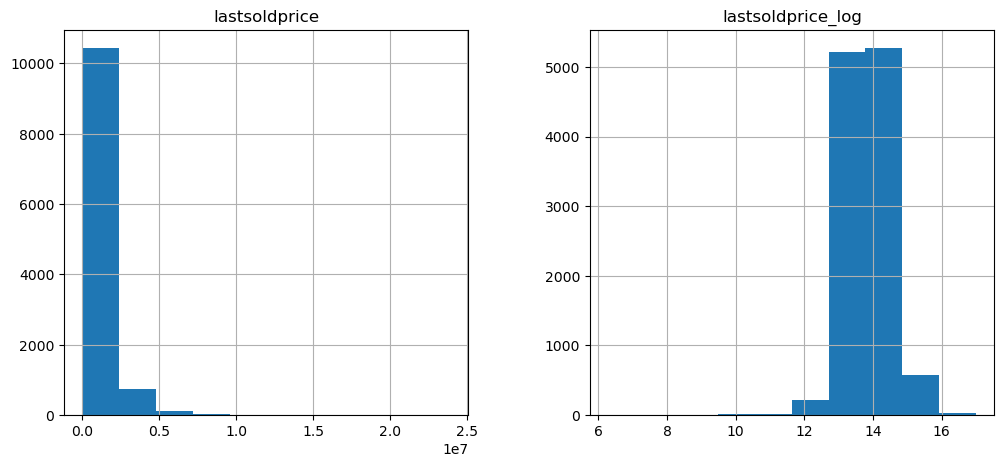

In [74]:
data_processed[['lastsoldprice', 'lastsoldprice_log']].hist(figsize=(12, 5));

#### Бинаризация

In [75]:
data_processed['one_bed'] = (data_processed['bedrooms'] == 1).astype('int')
data_processed.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,st,sutter,ter,unit,van,way,cluster,price_per_sqft,lastsoldprice_log,one_bed
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,1.455667e+09,1300000.0,37.778705,-122.412635,South of Market,4,...,0.207690,0.0,0.0,0.498299,0.0,0.0,4,1246.404602,14.077875,0
1,260 King St UNIT 475,1.0,1.0,903.0,1.455667e+09,750000.0,37.777641,-122.393417,South of Market,3,...,0.167233,0.0,0.0,0.401232,0.0,0.0,9,830.564784,13.527828,1
2,560 Missouri St # B,4.0,3.0,1425.0,1.455667e+09,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,1.000000,0.0,0.0,0.000000,0.0,0.0,0,1049.122807,14.217637,0
3,350 Missouri St,3.0,3.0,2231.0,1.455667e+09,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,1.000000,0.0,0.0,0.000000,0.0,0.0,0,1210.219632,14.808762,0
4,3658 Folsom St,3.0,3.0,1300.0,1.455667e+09,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,0.247710,0.0,0.0,0.000000,0.0,0.0,2,1176.923077,14.240778,0


#### Биннинг (дискретизация)

In [76]:
pd.cut(data_processed['lastsoldprice'], bins=3)

0        (-23353.465, 7963356.667]
1        (-23353.465, 7963356.667]
2        (-23353.465, 7963356.667]
3        (-23353.465, 7963356.667]
4        (-23353.465, 7963356.667]
                   ...            
11325    (-23353.465, 7963356.667]
11326    (-23353.465, 7963356.667]
11327    (-23353.465, 7963356.667]
11328    (-23353.465, 7963356.667]
11329    (-23353.465, 7963356.667]
Name: lastsoldprice, Length: 11330, dtype: category
Categories (3, interval[float64, right]): [(-23353.465, 7963356.667] < (7963356.667, 15926178.333] < (15926178.333, 23889000.0]]

In [77]:
pd.cut(data_processed['lastsoldprice'], bins=3, labels=['1', '2', '3'])

0        1
1        1
2        1
3        1
4        1
        ..
11325    1
11326    1
11327    1
11328    1
11329    1
Name: lastsoldprice, Length: 11330, dtype: category
Categories (3, object): ['1' < '2' < '3']

In [78]:
data_processed['lastsoldprice_cat'] = (pd.cut(data_processed['lastsoldprice'], bins=3, labels=False)).astype('int')
data_processed.head()

,z_address,bathrooms,bedrooms,finishedsqft,lastsolddate,lastsoldprice,latitude,longitude,neighborhood,totalrooms,...,sutter,ter,unit,van,way,cluster,price_per_sqft,lastsoldprice_log,one_bed,lastsoldprice_cat
0,1160 Mission St UNIT 2007,2.0,2.0,1043.0,1.455667e+09,1300000.0,37.778705,-122.412635,South of Market,4,...,0.0,0.0,0.498299,0.0,0.0,4,1246.404602,14.077875,0,0
1,260 King St UNIT 475,1.0,1.0,903.0,1.455667e+09,750000.0,37.777641,-122.393417,South of Market,3,...,0.0,0.0,0.401232,0.0,0.0,9,830.564784,13.527828,1,0
2,560 Missouri St # B,4.0,3.0,1425.0,1.455667e+09,1495000.0,37.759198,-122.396516,Potrero Hill,6,...,0.0,0.0,0.000000,0.0,0.0,0,1049.122807,14.217637,0,0
3,350 Missouri St,3.0,3.0,2231.0,1.455667e+09,2700000.0,37.761886,-122.396769,Potrero Hill,10,...,0.0,0.0,0.000000,0.0,0.0,0,1210.219632,14.808762,0,0
4,3658 Folsom St,3.0,3.0,1300.0,1.455667e+09,1530000.0,37.740795,-122.413453,Bernal Heights,4,...,0.0,0.0,0.000000,0.0,0.0,2,1176.923077,14.240778,0,0


In [79]:
model = get_score(data_processed.drop(columns=exclude_columns), data_processed['zestimate'], is_return=True)

0.8163967896487345


## Отбор признаков

https://scikit-learn.org/stable/modules/feature_selection.html

In [80]:
model.coef_

array([ 9.91543386e+04,  4.95087355e+03,  5.54741365e+05,  3.24462803e+05,
       -2.51751398e+05,  2.42414414e+03,  4.26395644e+04,  2.87453204e+04,
        1.39687007e+02, -9.77027664e+04, -1.04465135e+04, -3.35926825e+04,
       -5.30936161e+03, -3.95155870e+03, -4.07500272e+04, -3.50808381e+03,
        1.21026374e+05,  4.53860237e+03, -2.38939140e+03,  3.40252608e+04,
        2.63985713e+04,  1.84005853e+04, -1.30336641e+05, -8.07142806e+04,
        4.19445243e+04, -1.71516760e+04,  2.76505255e+04, -5.41031036e+03,
       -3.92550418e+03, -1.98666770e+04,  6.65156729e+04,  3.56768271e+04,
       -7.53652232e+03, -2.52609186e+04, -2.49036587e+04,  1.82172504e+04,
       -4.16251101e+04, -1.62852937e+04,  4.42830745e+04, -2.97644545e+04,
       -4.58101653e+04, -3.56652699e+04, -5.50730681e+04, -8.24132162e+04,
       -4.93441890e+04, -2.55960446e+04, -6.87019562e+04, -3.58551649e+04,
       -4.31234378e+03, -5.49155792e+04,  4.00732308e+04, -1.44069693e+04,
       -4.80834342e+04, -

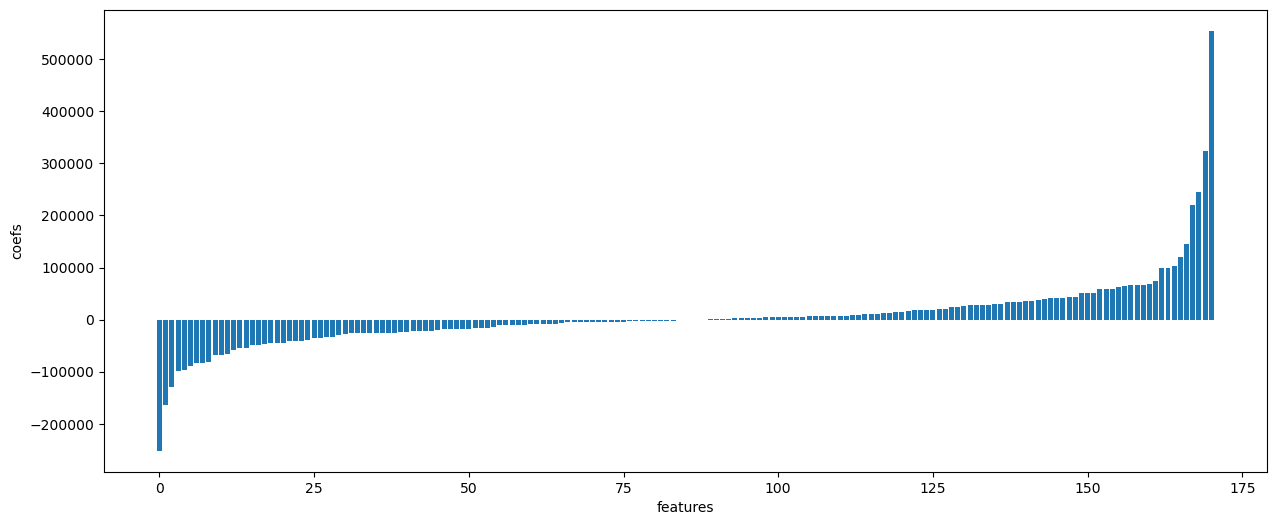

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.bar(np.arange(len(model.coef_)), sorted(model.coef_))
plt.xlabel('features')
plt.ylabel('coefs');

### Одномерный


- For regression: f_regression, mutual_info_regression

- For classification: chi2, f_classif, mutual_info_classif



In [82]:
y = data_processed['zestimate']

In [83]:
X = data_processed.drop(columns=exclude_columns)

In [84]:
X.shape

(11330, 171)

In [85]:
%%time
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(f_regression, k=150)
X_new = selector.fit_transform(X, y)
X_new.shape

CPU times: total: 15.6 ms
Wall time: 49.1 ms


(11330, 150)

In [86]:
model = get_score(X_new, y, is_return=True)

0.8169280789468357


In [87]:
%%time
from sklearn.feature_selection import mutual_info_regression

selector = SelectKBest(mutual_info_regression, k=100)
X_ne = selector.fit_transform(X, y)
X_ne.shape

CPU times: total: 11.5 s
Wall time: 11.2 s


(11330, 100)

In [88]:
get_score(X_ne, y)

0.8153209756860489

In [89]:
from sklearn.feature_selection import SelectPercentile

selector = SelectPercentile(f_regression, percentile=80)
X_new = selector.fit_transform(X, y)
X_new.shape

(11330, 136)

In [90]:
get_score(X_new, y)

0.816805634855519

In [91]:
%%time
selector = SelectPercentile(mutual_info_regression, percentile=50)
X_ne = selector.fit_transform(X, y)
X_ne.shape

CPU times: total: 11.2 s
Wall time: 11.6 s


(11330, 85)

In [92]:
get_score(X_ne, y)

0.8013377602036678

### Рекурсивный

In [93]:
from sklearn.feature_selection import RFE

selector = RFE(model, n_features_to_select=130, step=1)
selector = selector.fit(X_new, y)
selector.support_

array([ True,  True, False,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [94]:
selector.ranking_

array([1, 1, 4, 1, 1, 7, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1])

In [95]:
X_new2 = X_new[:, selector.support_]
X_new2.shape

(11330, 130)

In [96]:
X_new2 = selector.transform(X_new)
X_new2.shape

(11330, 130)

In [97]:
get_score(X_new2, y)

0.7510477087859585

### SelectFromModel

In [98]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(model, prefit=False, max_features=100, threshold=-np.inf)
X_new2 = selector.fit_transform(X_new, y)
X_new2.shape

(11330, 100)

In [99]:
model = get_score(X_new2, y, is_return=True)

0.747293929452399


### Переборный

In [100]:
# 1 2 3

# 1: 1, 2, 3
# 2: 12, 13
# 3: 123


In [101]:
%%time
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    model, n_features_to_select=70, direction="forward"
)
sfs_forward.fit(X_new2, y)

CPU times: total: 10min 31s
Wall time: 2min 14s


,estimator,LinearRegression()
,n_features_to_select,70
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [102]:
X_new3 = X_new2[:, sfs_forward.get_support()]
X_new3.shape

(11330, 70)

In [103]:
X_new3 = sfs_forward.transform(X_new2)
X_new3.shape

(11330, 70)

In [104]:
model = get_score(X_new3, y, is_return=True)

0.7481078217792263


In [105]:
# 1 2 3

# 1: 123
# 2: 12, 13, 32
# 3: 1, 2

In [106]:
%%time
sfs_backward = SequentialFeatureSelector(
    model, n_features_to_select=40, direction="backward"
)
sfs_backward.fit(X_new3, y)

CPU times: total: 7min 19s
Wall time: 1min 23s


,estimator,LinearRegression()
,n_features_to_select,40
,tol,None
,direction,'backward'
,scoring,None
,cv,5
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [107]:
X_new4 = sfs_backward.transform(X_new3)
X_new4.shape

(11330, 40)

In [108]:
model = get_score(X_new4, y, is_return=True)

0.7462557914929628


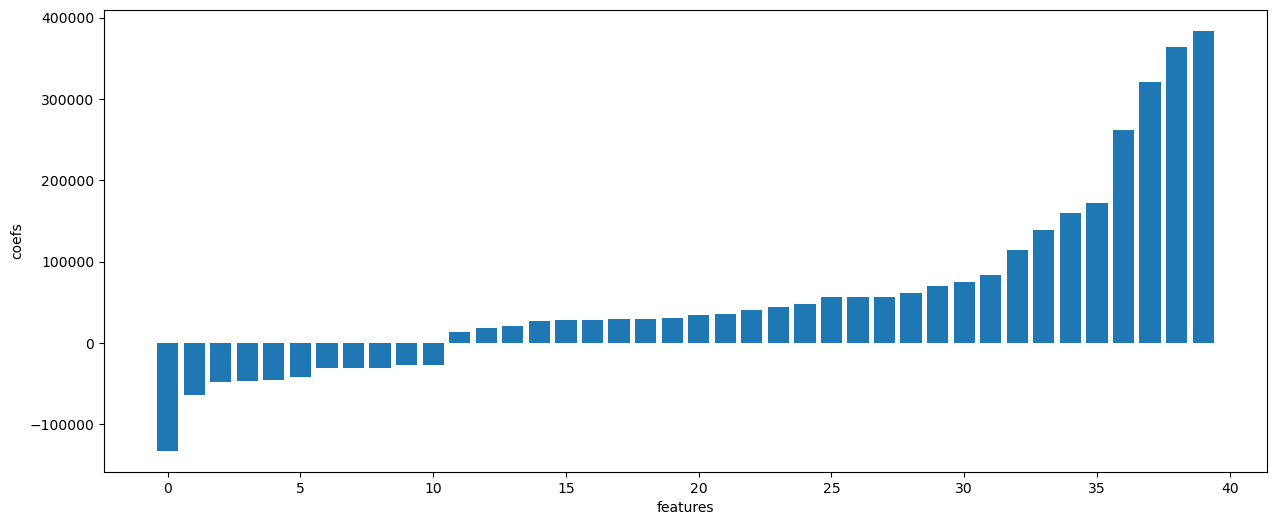

In [109]:
plt.figure(figsize=(15, 6))
plt.bar(np.arange(len(model.coef_)), sorted(model.coef_))
plt.xlabel('features')
plt.ylabel('coefs');